# PyFC: Algorithmic Features -- Sparsification, Smoothing, and the Finite-MC Correction

Three independent knobs that trade off speed, visual polish, and statistical rigor -- each
demonstrated here by running the *same* small 3-parameter binned model with the knob on vs.
off, so you can see exactly what each one changes:

1. **`sparsify_grid`** -- trades a small amount of 2D-contour precision for a large reduction
   in the number of Monte Carlo toy batches computed.
2. **`smooth_1d`/`smooth_2d`** -- purely cosmetic: smooths the *plotted* profile/contour, does
   not touch the underlying `results` data.
3. **`use_finite_mc_correction_binned`** -- a genuine statistical correction: accounts for
   finite simulated-template statistics, correctly *widening* intervals when templates are
   themselves uncertain.

As elsewhere in these tutorials, `n_toys` and the grid resolution are kept small for speed.

In [ ]:
%matplotlib inline

import time

import numpy as np
from numba import njit

from pyfc import compute_fc_intervals, generate_corner_plot

np.random.seed(20260727)

N_TOYS = 15
CORES = 2

S_template = np.array([0.1, 0.5, 2.0, 5.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1])
observed_counts = np.array([20, 7, 2, 0])


@njit(fastmath=True, nogil=True)
def compute_rates(params, S_sumw2, B_sumw2):
    """ params = (flux_norm * spectral_index, bg_norm); see 01_pyfc_quickstart_tutorial.ipynb. """
    mu = (params[0] * params[1]) * S_template + params[2] * B_template
    sigma2 = ((params[0] * params[1])**2) * S_sumw2 + (params[2]**2) * B_sumw2
    return mu, sigma2


grids = [np.linspace(0.5, 2.0, 8), np.linspace(0.5, 2.0, 8), np.linspace(0.5, 1.5, 8)]


def print_1d_bounds(results, n_params, cl):
    for p_idx in range(n_params):
        test_pts = results[f"1d_test_p{p_idx+1}"]
        accepted = results[f"1d_accepted_p{p_idx+1}"][cl]
        accepted_pts = test_pts[accepted]
        bounds = f"[{accepted_pts.min():.4g}, {accepted_pts.max():.4g}]" if len(accepted_pts) else "empty"
        print(f"  param{p_idx+1} (CL {cl}): {bounds}")

## 1. `sparsify_grid`: coarse-scan-then-refine vs. exhaustive

To calculate exact 2D contours, PyFC evaluates Monte Carlo toys at every 2D grid node --
$N \times N$ toy batches per parameter pair. `sparsify_grid=True` instead:

1. Evaluates only a coarse, widely-spaced sub-grid exactly.
2. Fits a `RectBivariateSpline` to interpolate the $t_{\text{critical}}$ surface from those
   coarse nodes across the full grid.
3. Traces the *approximate* inclusion/exclusion boundary from that interpolation, and only
   then evaluates the remaining high-resolution nodes *on that boundary* exactly.

The interior (deep inside the confidence region) and exterior (far outside it) are never
exhaustively evaluated -- only the boundary is. The two 1D bound sets below should agree
almost exactly; the small numerical differences that remain come from the interpolation step
of the *2D* surface, and 1D bounds don't depend on `sparsify_grid` at all (that knob is
2D-specific, see `orchestrator.py`'s Phase 2).

--- Running WITHOUT sparsification (exhaustive 2D grid) ---


Time: 40.84s
  param1 (CL 0.9): [0.5, 0.9]
  param2 (CL 0.9): [0.5, 1.5]
  param3 (CL 0.9): [1.033, 1.5]

--- Running WITH sparsification (coarse pass + boundary tracing) ---


Time: 14.55s
  param1 (CL 0.9): [0.5, 0.7]
  param2 (CL 0.9): [0.5, 1.1]
  param3 (CL 0.9): [0.9, 1.5]

Speedup: 2.81x (grows much larger still at finer grid resolutions)


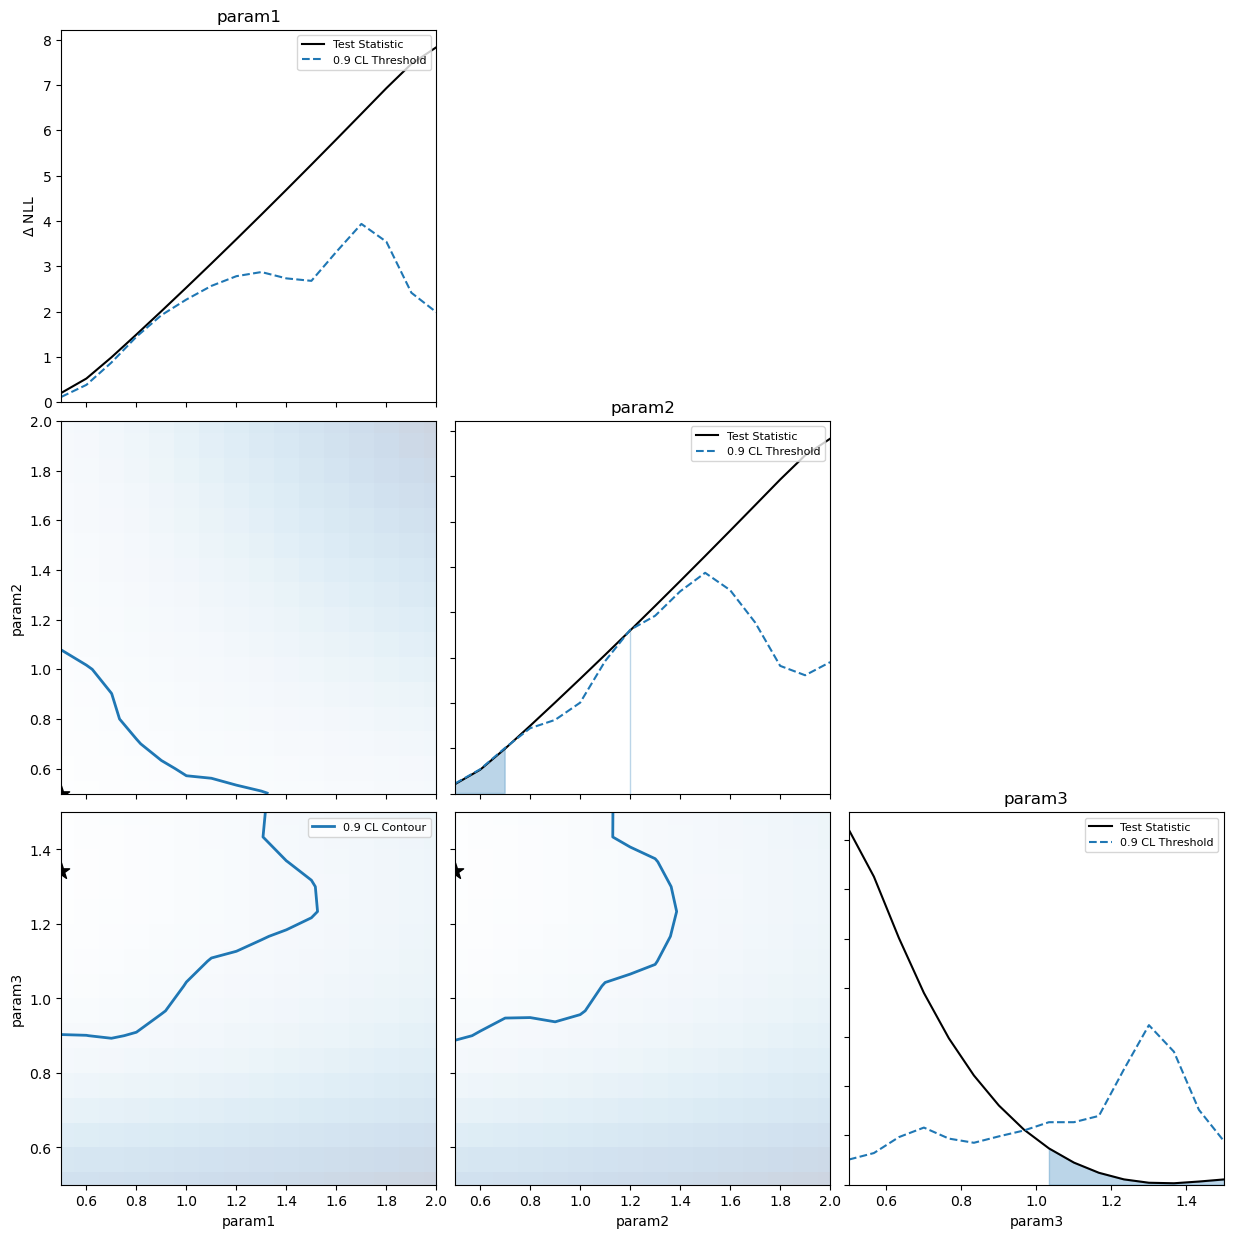

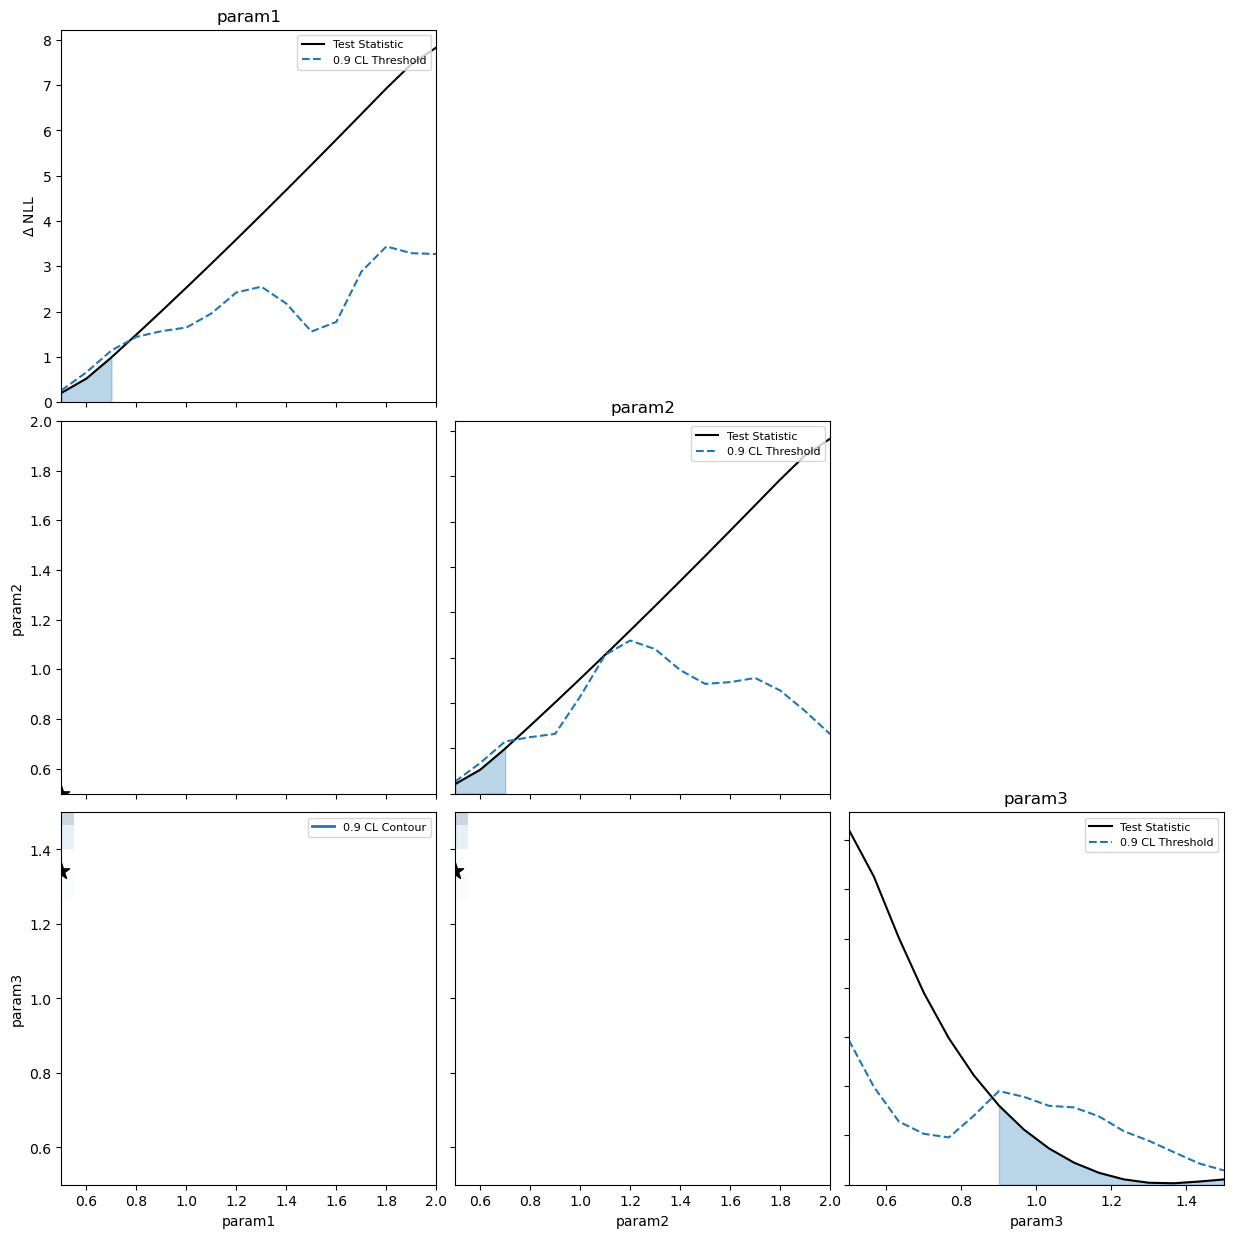

In [2]:
ZERO_SUMW2 = np.zeros_like(observed_counts).astype(float)

# A finer grid than the rest of this notebook uses: sparsify_grid's coarse-pass
# step size is len(grid)//5, so an 8-point grid (like elsewhere in this notebook)
# rounds that down to a step of 1 -- no actual skipping, no visible speedup. 16
# points/dim is the smallest resolution here that shows the effect clearly while
# still running in about a minute total.
grids_sparse_demo = [np.linspace(0.5, 2.0, 16), np.linspace(0.5, 2.0, 16), np.linspace(0.5, 1.5, 16)]

print("--- Running WITHOUT sparsification (exhaustive 2D grid) ---")
t0 = time.time()
results_no_sparse, _ = compute_fc_intervals(
    data=observed_counts, grids=grids_sparse_demo, compute_rates_func=compute_rates,
    S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
    cl=[0.90], n_toys=10, num_cores=4, verbose=0,
    sparsify_grid=False, save_directory="algorithmic_features_output/sparse_off",
)
t_no_sparse = time.time() - t0
print(f"Time: {t_no_sparse:.2f}s")
print_1d_bounds(results_no_sparse, n_params=3, cl=0.90)

print("\n--- Running WITH sparsification (coarse pass + boundary tracing) ---")
t0 = time.time()
results_sparse, _ = compute_fc_intervals(
    data=observed_counts, grids=grids_sparse_demo, compute_rates_func=compute_rates,
    S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
    cl=[0.90], n_toys=10, num_cores=4, verbose=0,
    sparsify_grid=True, save_directory="algorithmic_features_output/sparse_on",
)
t_sparse = time.time() - t0
print(f"Time: {t_sparse:.2f}s")
print_1d_bounds(results_sparse, n_params=3, cl=0.90)

print(f"\nSpeedup: {t_no_sparse / t_sparse:.2f}x (grows much larger still at finer grid resolutions)")


## 2. `smooth_1d`/`smooth_2d`: cosmetic plot smoothing

At low grid resolution, 1D profiles and 2D contours can look jagged. `smooth_1d`/`smooth_2d`
apply a Gaussian-filter smoothing *only inside `generate_corner_plot`* -- they never touch the
`results` dictionary itself, so the underlying interval bounds you'd extract programmatically
are identical either way. We reuse the (unsparsified) `results_no_sparse` from above and just
call the plotting function twice with different smoothing settings.

--- Unsmoothed ---



--- Smoothed ---


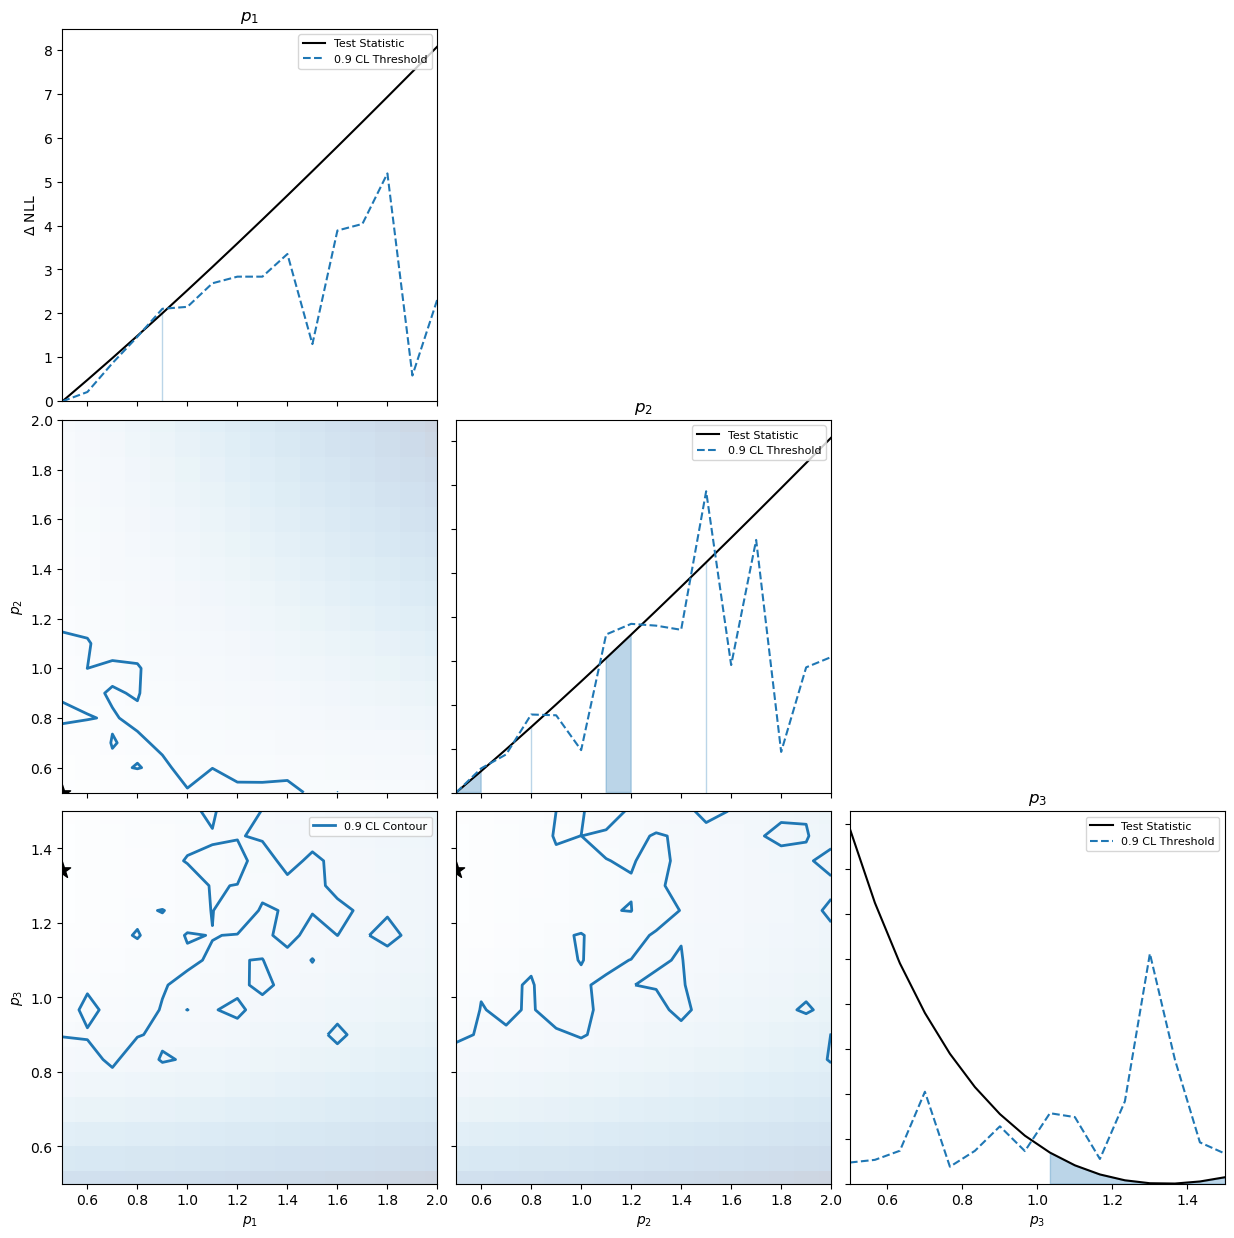

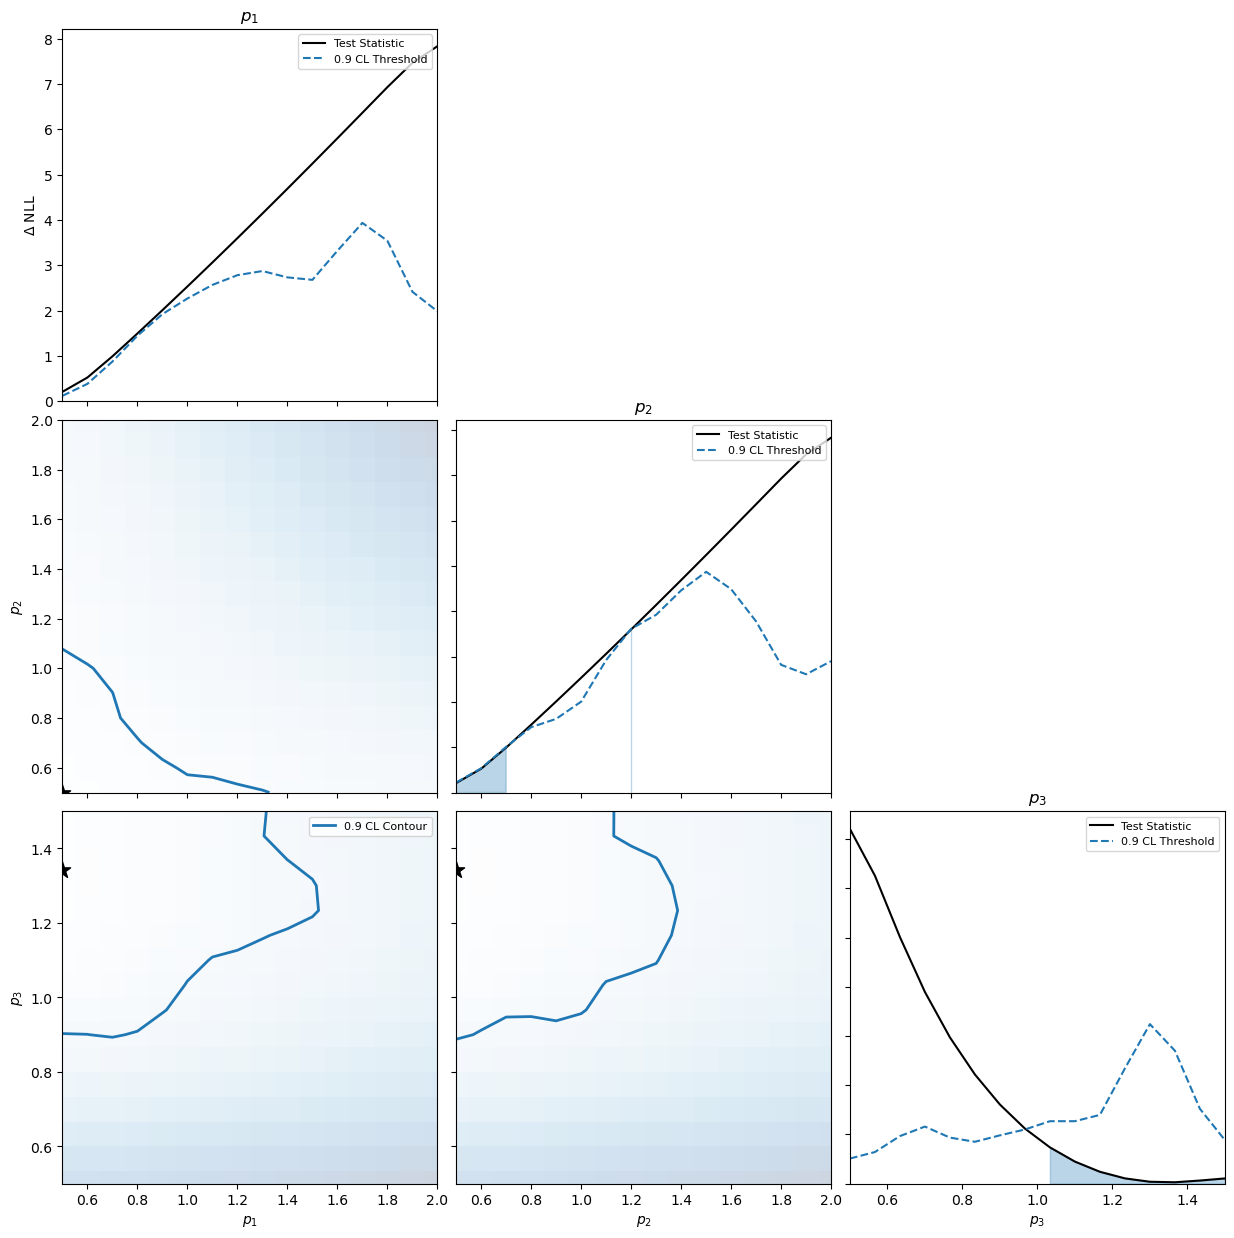

In [3]:
import os

plot_config_base = {
    "n_params": 3,
    "compute_1D_intervals": True,
    "compute_2D_intervals": True,
    "param_names": [r"$p_1$", r"$p_2$", r"$p_3$"],
    "cl": [0.90],
}

print("--- Unsmoothed ---")
cfg = dict(plot_config_base, smooth_1d=False, smooth_2d=False, save_directory="algorithmic_features_output/unsmoothed")
os.makedirs(cfg["save_directory"], exist_ok=True)
fig_unsmoothed = generate_corner_plot(results_no_sparse, cfg)

print("\n--- Smoothed ---")
cfg = dict(plot_config_base, smooth_1d=True, smooth_2d=True, save_directory="algorithmic_features_output/smoothed")
os.makedirs(cfg["save_directory"], exist_ok=True)
fig_smoothed = generate_corner_plot(results_no_sparse, cfg)


## 3. `use_finite_mc_correction_binned`: a real statistical correction

Unlike the two knobs above, this one changes the *statistics*, not just appearance or
runtime. If your MC templates were generated from a finite number of simulated events,
treating their per-bin counts as exact truths (the default, infinite-statistics assumption)
understates your true uncertainty -- the confidence intervals come out artificially tight.

`use_finite_mc_correction_binned=True` switches the per-bin likelihood from a pure Poisson
term to a Poisson-Gamma mixture (Negative Binomial), using the per-bin `S_sumw2`/`B_sumw2`
(sum of squared MC weights -- the per-bin variance of a weighted MC sample) to inflate the
effective uncertainty accordingly. To make the effect obvious here, we inject deliberately
*massive* template uncertainties and compare the two settings side by side -- the correction
should visibly **widen** the intervals; ignoring it when it applies gives false confidence.

--- WITHOUT finite-MC correction (ignores the huge template uncertainty) ---


  param1 (CL 0.9): [0.5, 0.5]
  param2 (CL 0.9): [0.5, 0.5]
  param3 (CL 0.9): [1.071, 1.5]

--- WITH finite-MC correction (accounts for it) ---


  param1 (CL 0.9): [0.7143, 1.143]
  param2 (CL 0.9): [0.7143, 0.9286]
  param3 (CL 0.9): [0.6429, 1.5]

(With only n_toys=10 and an 8-point grid, individual param bounds can wobble from MC
noise -- but the overall region should be visibly less constraining WITH the
correction than without it. Use a realistic n_toys for any conclusion you rely on.)


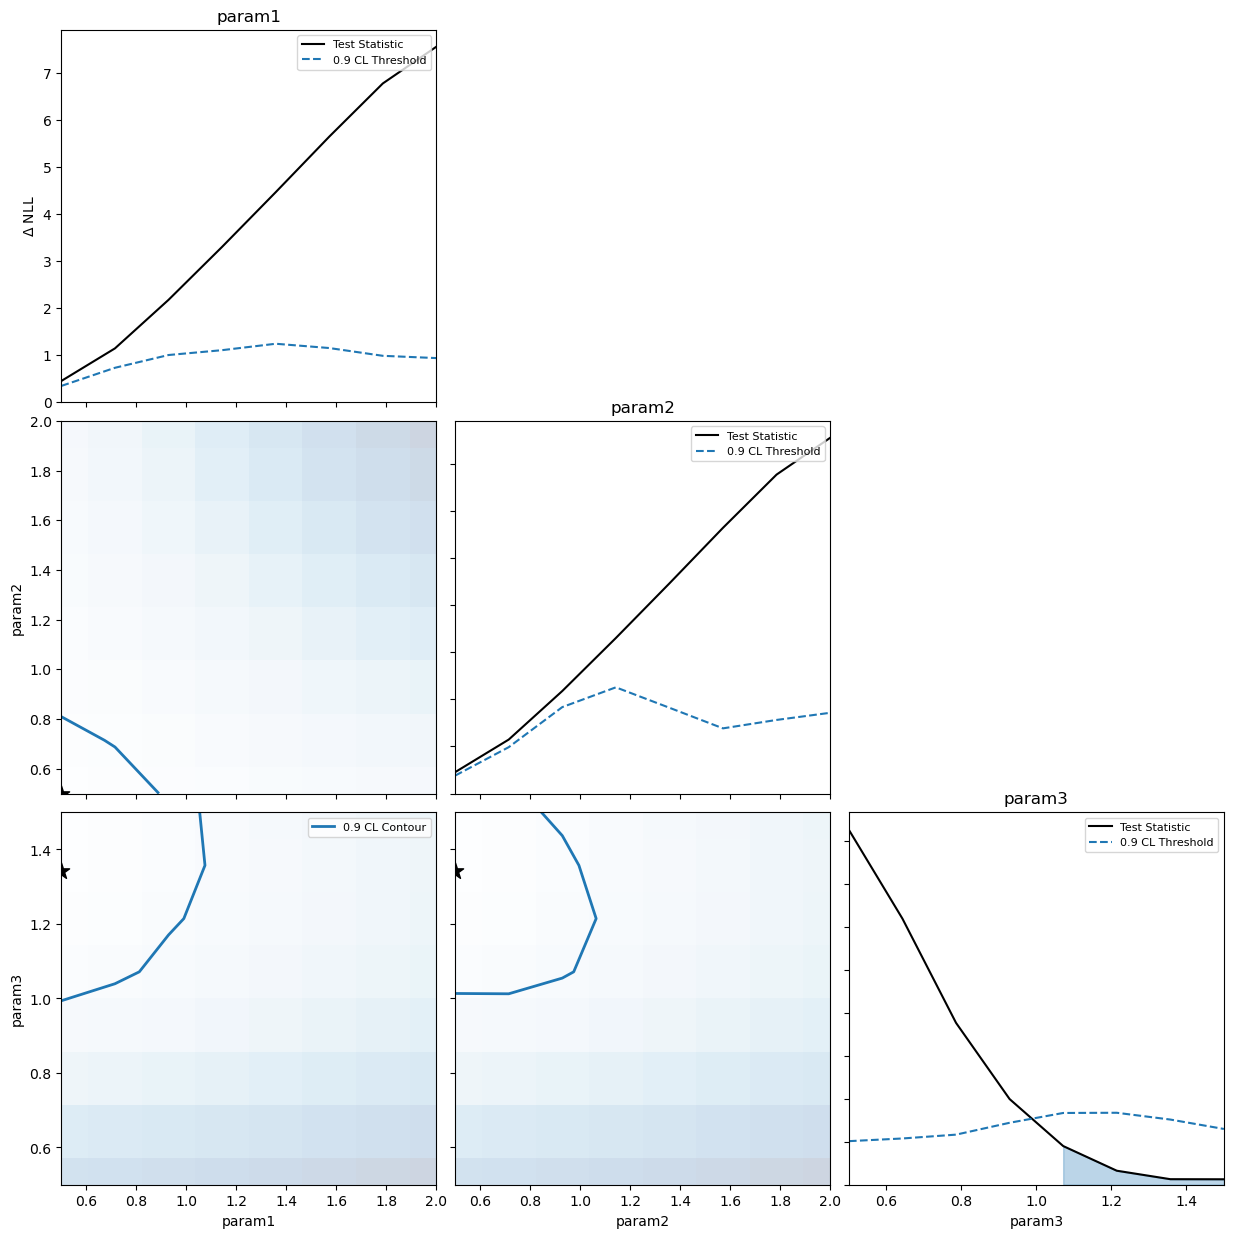

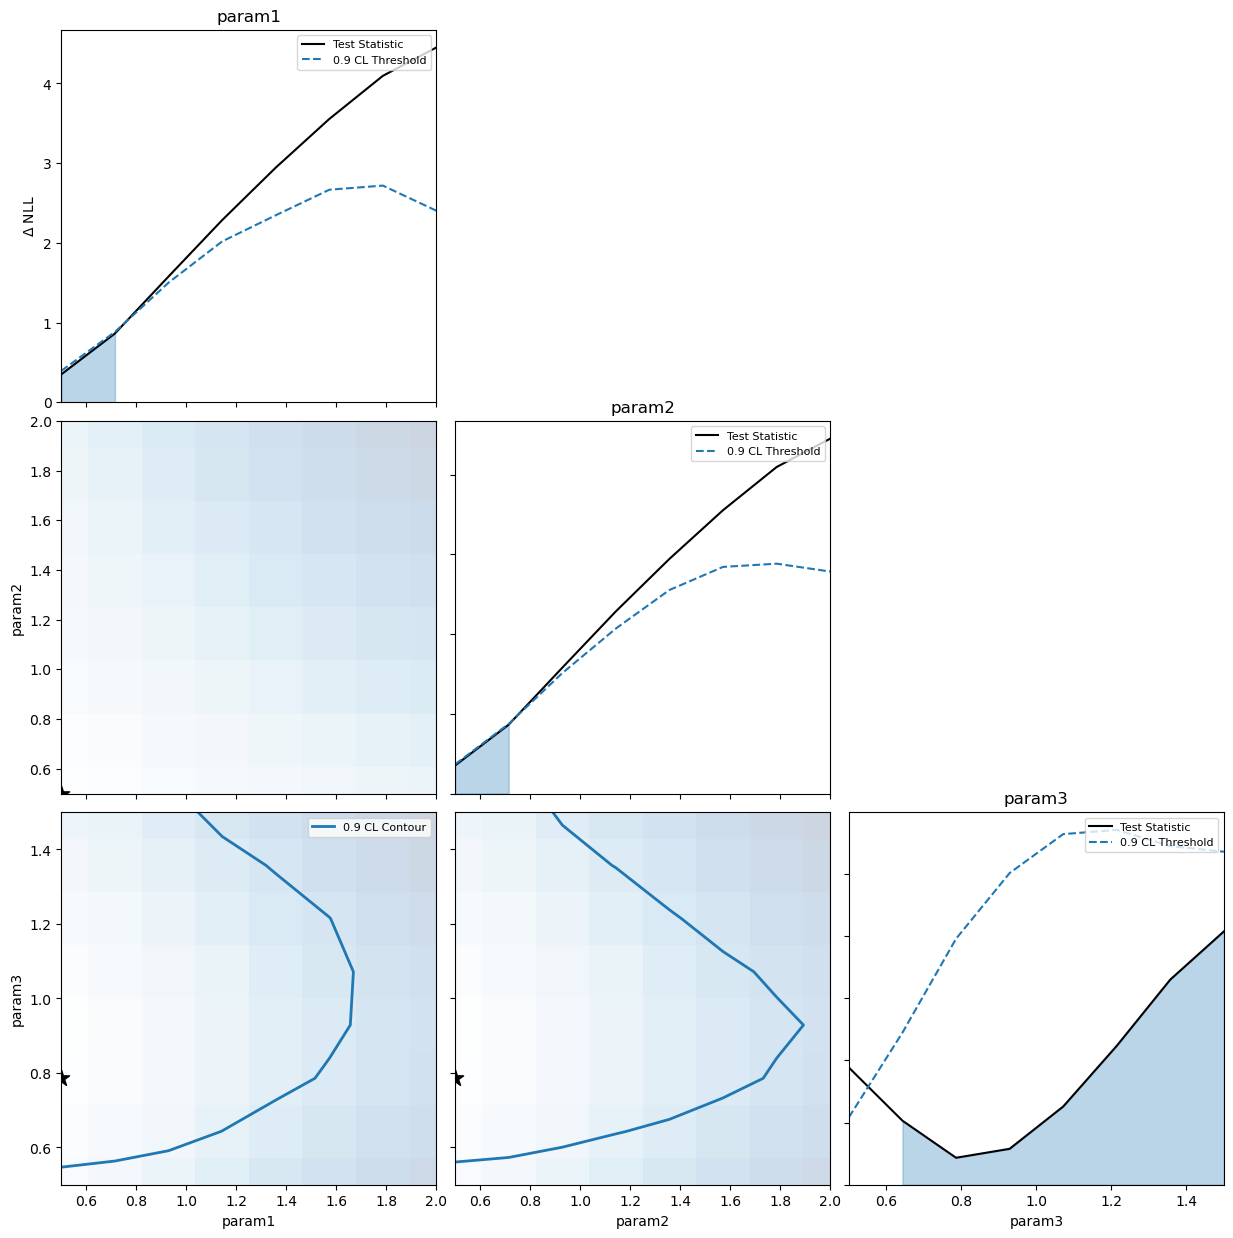

In [4]:
massive_S_sumw2 = S_template * 5.0
massive_B_sumw2 = B_template * 5.0

print("--- WITHOUT finite-MC correction (ignores the huge template uncertainty) ---")
results_no_fmc, _ = compute_fc_intervals(
    data=observed_counts, grids=grids, compute_rates_func=compute_rates,
    S_sumw2=massive_S_sumw2, B_sumw2=massive_B_sumw2,
    use_finite_mc_correction_binned=False,
    cl=[0.90], n_toys=N_TOYS, num_cores=CORES, verbose=0, sparsify_grid=False,
    save_directory="algorithmic_features_output/finite_mc_off",
)
print_1d_bounds(results_no_fmc, n_params=3, cl=0.90)

print("\n--- WITH finite-MC correction (accounts for it) ---")
results_fmc, _ = compute_fc_intervals(
    data=observed_counts, grids=grids, compute_rates_func=compute_rates,
    S_sumw2=massive_S_sumw2, B_sumw2=massive_B_sumw2,
    use_finite_mc_correction_binned=True,
    cl=[0.90], n_toys=N_TOYS, num_cores=CORES, verbose=0, sparsify_grid=False,
    save_directory="algorithmic_features_output/finite_mc_on",
)
print_1d_bounds(results_fmc, n_params=3, cl=0.90)

print("\n(With only n_toys=10 and an 8-point grid, individual param bounds can wobble from MC\n"
      "noise -- but the overall region should be visibly less constraining WITH the\n"
      "correction than without it. Use a realistic n_toys for any conclusion you rely on.)")

## 4. Disconnected accepted intervals

Under the Feldman-Cousins unified construction, the accepted region for a parameter can, in
principle, be genuinely disconnected -- e.g. a rate function that isn't monotonic in the
scanned parameter can cross the observed data at more than one point, separated by a region
where the fit is clearly worse. Reporting a single `[lo, hi]` span across the *whole* accepted
set would silently merge those separate intervals, including whatever rejected gap sits
between them -- misrepresenting the actual confidence region. `compute_fc_intervals`'s saved
`fc_results.json` instead always reports `interval_bounds` as a list of `[lo, hi]` pairs, one
per disconnected accepted run (a one-element list in the common single-interval case).

Here, `mu(x) = 5 + 4*sin(2*pi*x)` oscillates through the observed count (5) more than once
over `x` in `[0, 1]`, with a deep dip near `x=0.75` -- a deliberately non-monotonic toy model,
not a realistic physical one, chosen specifically to make this concrete.

interval_bounds: [[0.0, 0.225], [0.275, 0.6000000000000001], [0.9, 1.0]]
-> 3 disconnected accepted interval(s), reported separately (not merged).


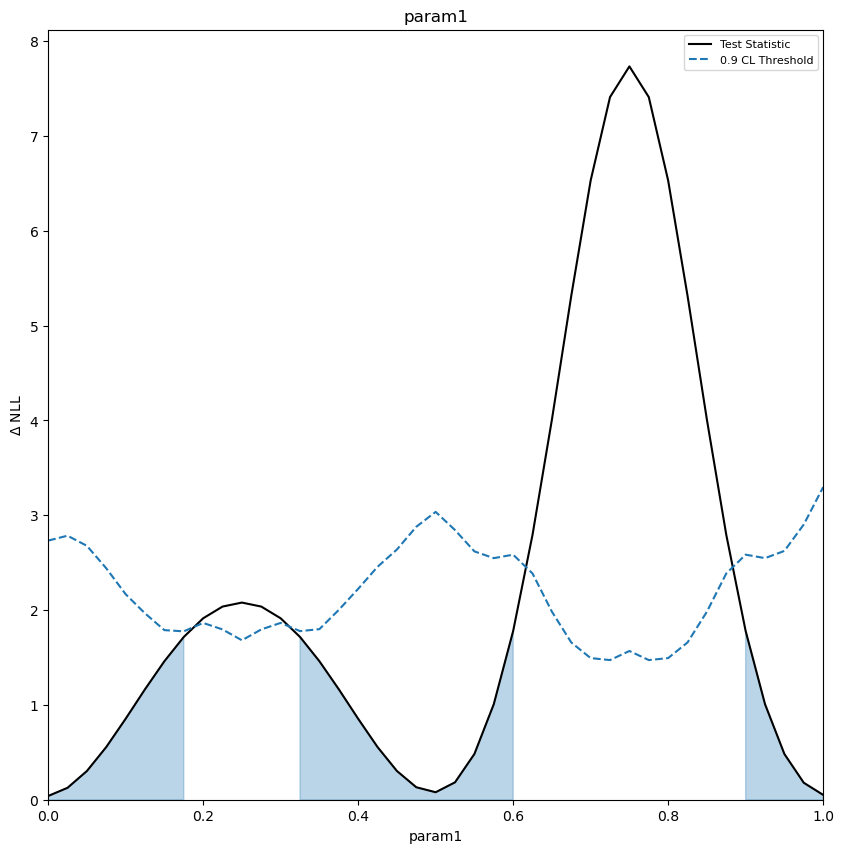

In [5]:
import json


@njit(fastmath=True, nogil=True)
def oscillating_rate_func(params, S_sumw2, B_sumw2):
    mu = np.array([5.0 + 4.0 * np.sin(2.0 * np.pi * params[0])])
    return mu, np.array([0.0])


results_disc, _ = compute_fc_intervals(
    data=np.array([5.0]), grids=[np.linspace(0.0, 1.0, 41)],
    compute_rates_func=oscillating_rate_func,
    S_sumw2=np.zeros(1), B_sumw2=np.zeros(1),
    cl=[0.90], n_toys=300, strategy="grid", num_cores=1, verbose=0,
    sparsify_grid=False, compute_1D_intervals=True, compute_2D_intervals=False,
    output_file="fc_results", save_directory="algorithmic_features_output/disconnected",
)

with open("algorithmic_features_output/disconnected/fc_results.json") as f:
    saved = json.load(f)
intervals = saved["1d_intervals"]["param1"]["thresholds"]["0.9"]["interval_bounds"]

print(f"interval_bounds: {intervals}")
print(f"-> {len(intervals)} disconnected accepted interval(s), reported separately (not merged).")

## Next steps

See `05_pyfc_strategy_comparison_tutorial.ipynb` for how the choice of optimizer strategy
interacts with these same knobs, and for building custom plots directly from PyFC's saved
`.json`/`.npz` output.